In [1]:
import os
import glob
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon

import warnings
warnings.filterwarnings("ignore")

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Global variables
media = ["FAT", "FA"]
media_titles = ["FAT", "FA"]
nmedia = 2
nreplicates=3
chan_r = 0
chan_g = 1
thresholds_to_try = np.linspace(0,1,101)
chosen_thr = 80
plots_prefix = "fa"
ring_width = 1

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
cfu_dir = proj_dir / 'cfu_counts' / 'raw_data'
if ring_width == 5:
   plot_dir = proj_dir / 'figures' / 'AllSets_FA'
elif ring_width == 1:
   plot_dir = proj_dir / 'figures_ring_1' / 'AllSets_FA'
if not os.path.exists(plot_dir):
   os.makedirs(plot_dir)
   
# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *
from _image_analysis_functions import *

# Functions
def significance_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    
def add_sig_bar(ax, x1, x2, y, text,h = 0.01):
    ax.plot([x1,x2], [y, y], color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=14)

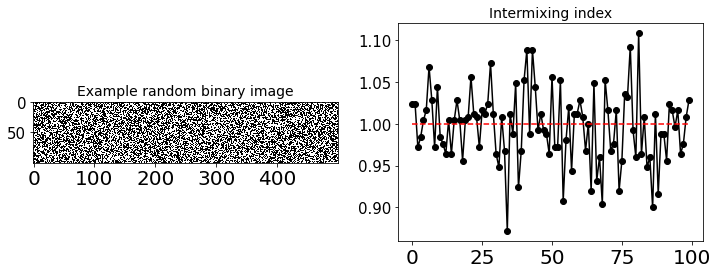

In [2]:
x = np.random.randint(2, size=(100,500))
fig, ax = plt.subplots(figsize=(12,4),ncols=2,nrows=1)
ax[0].imshow(x, cmap='gray', interpolation='none')
intermixing_values = intermixing_index(x)
ax[1].plot(intermixing_values, marker='o', color='black')
ax[1].hlines(y=1, xmin=0, xmax=len(intermixing_values)-1, color='red', linestyle='--')
ax[0].set_title("Example random binary image", fontsize=14)
ax[1].set_title("Intermixing index", fontsize=14)
plt.show()

In [2]:
# Load CFU data
all_cfu_files = glob.glob(str(cfu_dir / '*SET*'))
cfu_df = pd.read_excel(all_cfu_files[0])
for file in all_cfu_files[1:]:
    cfu_df2 = pd.read_excel(file)
    cfu_df = pd.concat([cfu_df,cfu_df2])
cfu_df.reset_index(drop=True,inplace=True)
cfu_df = cfu_df[cfu_df['partner'] != "OaWT"]
cfu_df = cfu_df[cfu_df['strain'] != "OaWT"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-control"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-border"]
cfu_df = cfu_df[cfu_df['condition'] != "FAT-border"].copy()
cfu_df.head()

,strain,replicate,condition,culture,partner,dilution,count,day,comments,CFUs,SET
0,Oa,1,FA-FAT,mono,none,4.0,70.0,0.0,NaN,70000.0,3
1,G3,1,FA-FAT,mono,none,4.0,59.0,0.0,NaN,59000.0,3
2,G4,1,FA-FAT,mono,none,4.0,67.0,0.0,NaN,67000.0,3
3,G5,1,FA-FAT,mono,none,4.0,28.0,0.0,NaN,28000.0,3
4,G6,1,FA-FAT,mono,none,4.0,69.0,0.0,NaN,69000.0,3


In [3]:
# Load image analysis data
if ring_width == 5:
    data = pd.read_csv('fa_image_analysis.csv')
elif ring_width == 1:
    data = pd.read_csv('fa_image_analysis_ring_1.csv')
data.head()

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
0,AeCa,FAT,1,"[0.0032563109607619076, 0.0021708739738412718,...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.020642,507.270323,34.708377,0.858366
1,AeCa,FAT,2,"[0.04263766035258594, 0.03717129364071595, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.023708,320.718093,29.296464,0.859579
2,AeCa,FAT,3,"[0.09271943999091473, 0.08967945835186834, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.021737,854.628492,27.016859,0.903959
3,AeCa,FA,1,"[0.03187514401140148, 0.04010098762724702, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.042457,145.375508,13.512418,0.848801
4,AeCa,FA,2,"[0.005595635126494635, 0.007833889177092488, 0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.042431,445.143851,13.538552,0.863393


In [4]:
max_ss = data[data["media"]=="FA"]["sector_size_Oa"].max()
data[data["sector_size_Oa"]==max_ss]

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
4,AeCa,FA,2,"[0.005595635126494635, 0.007833889177092488, 0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.042431,445.143851,13.538552,0.863393


In [5]:
partners_to_exclude_im = pd.unique(data[data["oa_frequency"] > 0.85]["partner"])
print(f"Partners excluded due to Oa dominance in FAT (image analysis): {partners_to_exclude_im}")

Partners excluded due to Oa dominance in FAT (image analysis): ['AeCa' 'BrVe' 'G1' 'G5' 'G6' 'GN1' 'GN3' 'KlPn' 'PrRe' 'PsFl' 'PsPs' 'S2'
 'SC1' 'SC18']


In [6]:
# Subset data to colonies for which Oa does not dominate in FAT (i.e., Oa frequency < 0.9)
partners_to_exclude_cfu = []
for partner in all_partners_in_collection:
    mean_oa_freq_fat = np.mean([get_oa_freq(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    if mean_oa_freq_fat >= 0.9:
        partners_to_exclude_cfu.append(partner)
print(f"Partners excluded due to Oa dominance in FAT: {partners_to_exclude_cfu}")

Partners excluded due to Oa dominance in FAT: ['AeCa', 'BrVe', 'CiFr', 'G3', 'GN1', 'G1', 'G5', 'G6', 'G8', 'KlPn', 'PsFu', 'PsFl', 'PsPs', 'PrRe', 'S2', 'SC12', 'SC14']


In [7]:
# Relative sector size
data["norm_oa_ss"] = data["sector_size_Oa"] / data["oa_frequency"]
data["norm_p_ss"] = data["sector_size_partner"] / (1-data["oa_frequency"])

In [8]:
partners_to_exclude_manual = ['BrVe','G1','G5','GN1','GN3','KlPn','PrRe','SC1','SC18']
data_no_dom = data[~data['partner'].isin(partners_to_exclude_manual)].copy()
print(f"Remaining partners for analysis: {len(data_no_dom['partner'].unique())}")

Remaining partners for analysis: 19


In [9]:
# Comparison between FAT and FA
data_pivot = data.pivot(index=["partner","replicate"], columns="media", values=["mean_intermixing","norm_oa_ss","norm_p_ss","sector_size_Oa","sector_size_partner","oa_frequency"]).reset_index()
data_pivot["delta_mean_intermixing"] = data_pivot["mean_intermixing"]["FA"] - data_pivot["mean_intermixing"]["FAT"]
data_pivot["delta_norm_oa_ss"] = data_pivot["norm_oa_ss"]["FA"] - data_pivot["norm_oa_ss"]["FAT"]
data_pivot["delta_norm_p_ss"] = data_pivot["norm_p_ss"]["FA"] - data_pivot["norm_p_ss"]["FAT"]
data_pivot["delta_sector_size_Oa"] = data_pivot["sector_size_Oa"]["FA"] - data_pivot["sector_size_Oa"]["FAT"]
data_pivot["delta_sector_size_partner"] = data_pivot["sector_size_partner"]["FA"] - data_pivot["sector_size_partner"]["FAT"]
data_pivot["delta_oa_frequency"] = data_pivot["oa_frequency"]["FA"] - data_pivot["oa_frequency"]["FAT"]
data_pivot["sign_delta_oa_frequency"] = np.sign(data_pivot["delta_oa_frequency"])
data_pivot.head()

partner replicate mean_intermixing            norm_oa_ss              \
media                                 FA       FAT          FA         FAT   
0        AeCa         1         0.042457  0.020642  171.271614  590.972263   
1        AeCa         2         0.042431  0.023708  515.574822  373.110462   
2        AeCa         3         0.037291  0.021737  423.086122  945.428128   
3        AlFa         1         0.042573  0.053123  315.753393  139.182657   
4        AlFa         2         0.042236  0.050938  197.473614  125.791368   

        norm_p_ss             sector_size_Oa              ...  \
media          FA         FAT             FA         FAT  ...   
0       89.368403  245.056307     145.375508  507.270323  ...   
1       99.106069  208.633769     445.143851  320.718093  ...   
2      100.791164  281.306180     356.399670  854.628492  ...   
3      339.555326  143.684427      10.886562   10.312314  ...   
4      217.187778  151.533468      10.229641   10.516341  ...   

      sector_size_partner oa_frequency           delta_mean_intermixing  \
media                 FAT           FA       FAT                          
0               34.708377     0.848801  0.858366               0.021816   
1               29.296464     0.863393  0.859579               0.018723   
2               27.016859     0.842381  0.903959               0.015554   
3              133.038569     0.034478  0.074092              -0.010550   
4              138.865050     0.051803  0.083601              -0.008702   

      delta_norm_oa_ss delta_norm_p_ss delta_sector_size_Oa  \
media                                                         
0          -419.700649     -155.687903          -361.894816   
1           142.464360     -109.527700           124.425758   
2          -522.342006     -180.515016          -498.228822   
3           176.570736      195.870898             0.574249   
4            71.682247       65.654310            -0.286699   

      delta_sector_size_partner delta_oa_frequency sign_delta_oa_frequency  
media                                                                       
0                    -21.195959          -0.009565                    -1.0  
1                    -15.757912           0.003814                     1.0  
2                    -11.130247          -0.061578                    -1.0  
3                    194.809550          -0.039614                    -1.0  
4                     67.071842          -0.031799                    -1.0  

[5 rows x 21 columns]

In [10]:
# Comparison between FAT and FA for colonies where Oa does not dominate in FAT
data_no_dom_pivot = data_no_dom.pivot(index=["partner","replicate"], columns="media", values=["mean_intermixing","norm_oa_ss","norm_p_ss","sector_size_Oa","sector_size_partner"]).reset_index()
data_no_dom_pivot["delta_sector_size_Oa"] = data_no_dom_pivot["sector_size_Oa"]["FA"] - data_no_dom_pivot["sector_size_Oa"]["FAT"]
data_no_dom_pivot["delta_sector_size_partner"] = data_no_dom_pivot["sector_size_partner"]["FA"] - data_no_dom_pivot["sector_size_partner"]["FAT"]
data_no_dom_pivot["delta_mean_intermixing"] = data_no_dom_pivot["mean_intermixing"]["FA"] - data_no_dom_pivot["mean_intermixing"]["FAT"]
data_no_dom_pivot["delta_norm_oa_ss"] = data_no_dom_pivot["norm_oa_ss"]["FA"] - data_no_dom_pivot["norm_oa_ss"]["FAT"]
data_no_dom_pivot["delta_norm_p_ss"] = data_no_dom_pivot["norm_p_ss"]["FA"] - data_no_dom_pivot["norm_p_ss"]["FAT"]

## Interactions plot

Mean Oa on BrVe in FAT: 1.3796847423814003
Mean Oa on BrVe in FA: 2.235212092075732
Mean Oa on GN1 in FA: 1.5918705031111235
Mean Oa on GN3 in FA: 2.2060549271359684
Mean and std Oa on GN3 in FA: 2.2060549271359684, 0.1374669725394895
Mean Oa on G1 in FA: 0.27079261477611555
Mean Oa on G5 in FA: 0.7945810887002586
Mean Oa on PsAe in FAT: 0.16770314555712307
Mean Oa on PsPs in FA: 0.1746833689072118
Mean Oa on PrRe in FA: 2.1687584152944734
Mean Oa on S1 in FAT: 0.057525109569574795
Mean and std Oa on SC1 in FA: nan, nan
Mean and std Oa on SC18 in FA: nan, nan


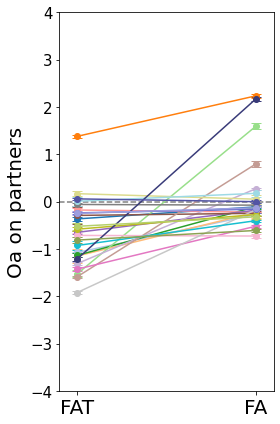

In [72]:
# Oa on P
fig, ax = plt.subplots(figsize=(4,6))
for partner in all_partners_in_collection:

    # Oa on Partners
    mean_oa_on_p_fat = np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fat = np.nanstd([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    if ttest_1samp([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)], 0, alternative="greater").pvalue < 0.05:
        print(f"Mean Oa on {partner} in FAT: {mean_oa_on_p_fat}")
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fa = np.nanstd([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if ttest_1samp([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)], 0,alternative="greater").pvalue < 0.05:
        print(f"Mean Oa on {partner} in FA: {mean_oa_on_p_fa}")
    if np.isnan(mean_oa_on_p_fa) | np.isnan(std_oa_on_p_fa) | np.isnan(mean_oa_on_p_fat) | np.isnan(std_oa_on_p_fat):
        print(f"Mean and std Oa on {partner} in FA: {mean_oa_on_p_fa}, {std_oa_on_p_fa}")
    else:
        ax.errorbar([0, 1],[mean_oa_on_p_fat, mean_oa_on_p_fa],yerr=[std_oa_on_p_fat, std_oa_on_p_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("Oa on partners")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_on_p.pdf", dpi=600)
plt.show()

Mean Oa on BrVe in FA: 2.235212092075732
Mean Oa on GN1 in FA: 1.5918705031111235
Mean Oa on GN3 in FA: 2.2060549271359684
Mean and std Oa on GN3 in FA: 2.2060549271359684, 0.1374669725394895
Mean Oa on G1 in FA: 0.27079261477611555
Mean Oa on G5 in FA: 0.7945810887002586
Mean Oa on PsAe in FA: 0.05133457636428093
Mean Oa on PsPs in FA: 0.1746833689072118
Mean Oa on PrRe in FA: 2.1687584152944734
Mean and std Oa on SC1 in FA: nan, nan
Mean and std Oa on SC18 in FA: nan, nan


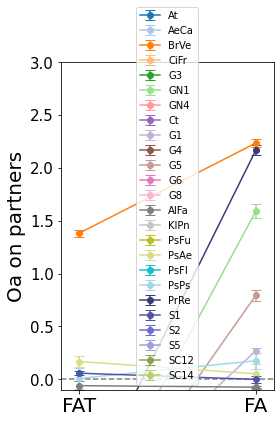

In [14]:
# Oa on P
fig, ax = plt.subplots(figsize=(4,6))
for partner in all_partners_in_collection:

    # Oa on Partners
    mean_oa_on_p_fat = np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fat = np.nanstd([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if mean_oa_on_p_fa > 0:
        print(f"Mean Oa on {partner} in FA: {mean_oa_on_p_fa}")
    std_oa_on_p_fa = np.nanstd([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_oa_on_p_fa) | np.isnan(std_oa_on_p_fa) | np.isnan(mean_oa_on_p_fat) | np.isnan(std_oa_on_p_fat):
        print(f"Mean and std Oa on {partner} in FA: {mean_oa_on_p_fa}, {std_oa_on_p_fa}")
    else:
        ax.errorbar([0, 1],[mean_oa_on_p_fat, mean_oa_on_p_fa],yerr=[std_oa_on_p_fat, std_oa_on_p_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("Oa on partners")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.legend()
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1,3)

plt.tight_layout()
plt.show()

In [74]:
# Mean and std of Oa on partners in FAT and FA
mean_oa_on_p_fat = np.nanmean([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
std_oa_on_p_fat = np.nanstd([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])

mean_oa_on_p_fa = np.nanmean([np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
std_oa_on_p_fa = np.nanstd([np.std([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])

mean_oa_on_p_fat, std_oa_on_p_fat, mean_oa_on_p_fa, std_oa_on_p_fa

(-0.6534715470530108,
 0.7001855057255584,
 0.18166845261490205,
 0.031052313162643633)

In [75]:
#Mean and std of partners on Oa in FAT and FA
mean_p_on_oa_fat = np.nanmean([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
std_p_on_oa_fat = np.nanstd([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
mean_p_on_oa_fa = np.nanmean([np.mean([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
std_p_on_oa_fa = np.nanstd([np.std([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in all_partners_in_collection])
mean_p_on_oa_fat, std_p_on_oa_fat, mean_p_on_oa_fa, std_p_on_oa_fa

(-0.34605685760163524,
 0.2999491985709869,
 1.5951581720338301,
 0.037898977754857274)

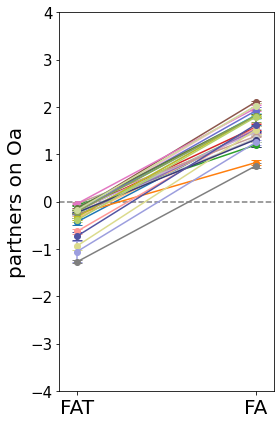

In [76]:
# P on Oa 
fig, ax = plt.subplots(figsize=(4,6))
for partner in all_partners_in_collection:

    # Oa on Partners
    mean_p_on_oa_fat = np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fat = np.nanstd([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_p_on_oa_fa = np.mean([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fa = np.nanstd([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_p_on_oa_fa) | np.isnan(std_p_on_oa_fa) | np.isnan(mean_p_on_oa_fat) | np.isnan(std_p_on_oa_fat):
        print(f"Mean and std {partner} on Oa in FA: {mean_p_on_oa_fa}, {std_p_on_oa_fa}")
    else:
        ax.errorbar([0, 1],[mean_p_on_oa_fat, mean_p_on_oa_fa],yerr=[std_p_on_oa_fat, std_p_on_oa_fa],marker="o",linestyle="-",capsize=5,color=color_dict[partner],label=partner)


ax.set_ylabel("partners on Oa")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)

plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_p_on_oa.pdf", dpi=600)
plt.show()

## Effect of changing medium on mixing and sector sizes

Wilcoxon signed-ranktest: stat=7.0, p-value=4.0372501439017805e-06
(-0.0018606027976538152, 0.061249700422536385)


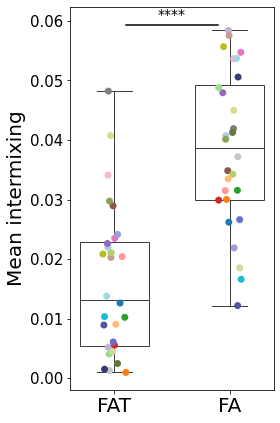

In [77]:
# Intermixing distributions
mean_intermixing = data.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_intermixing[mean_intermixing["media"] == "FAT"]["mean"], mean_intermixing[mean_intermixing["media"] == "FA"]["mean"],alternative="less")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_intermixing, ax=ax,x="media", y="mean", hue="partner",order=media_titles,palette=color_dict, size=7)
sns.boxplot(data=mean_intermixing, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean intermixing")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
print(plt.gca().get_ylim())
add_sig_bar(ax, 0.1, 0.9, mean_intermixing["mean"].max() + 0.001, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_intermixing.pdf", dpi=300)

Wilcoxon signed-rank test: stat=399.0, p-value=4.0372501439017805e-06
(-0.00931194379802459, 0.05718301905303992)


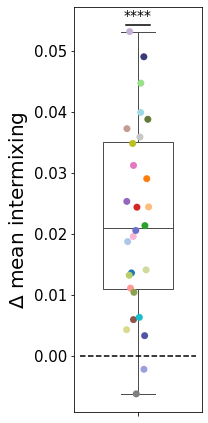

In [78]:
# Mean delta intermixing
mean_delta_intermixing = data_pivot.groupby("partner")["delta_mean_intermixing"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_intermixing["mean"] - 0, alternative="greater")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_intermixing, ax=ax, y="mean", hue="partner",palette=color_dict,size=7)
sns.boxplot(data=mean_delta_intermixing, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_intermixing["mean"].max() + 0.001, significance_stars(p), h = 0.0005)
ax.set_ylabel(r'$\Delta$ mean intermixing')
ax.legend([],[], frameon=False)
ax.set_xlabel("")
plt.tight_layout()
print(plt.gca().get_ylim())
plt.savefig(plot_dir / f"{plots_prefix}_delta_intermixing.pdf", dpi=300)

In [79]:
mean_delta_intermixing[mean_delta_intermixing["mean"]<0]

,partner,mean,std
1,AlFa,-0.006289,0.005852
23,S5,-0.002255,0.003922


Wilcoxon signed-ranktest: stat=397.0, p-value=4.988849443894224e-06
(-106.02666038924974, 2454.3916372768876)


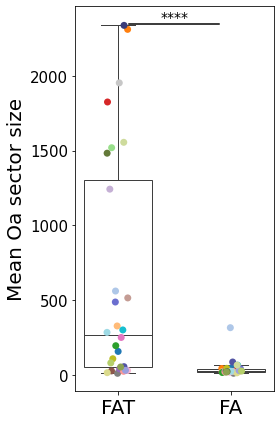

In [80]:
# Oa sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"],alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean Oa sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
ax.set_xlabel("")
print(plt.gca().get_ylim())
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 10, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_ss.pdf", dpi=600)
plt.show()

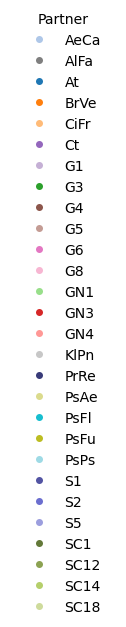

In [81]:
handles, labels = ax.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(2, 4))
ax_leg.axis("off")

ax_leg.legend(
    handles,
    labels,
    title="Partner",
    loc="center",
    fontsize=14,
    title_fontsize=14,
    frameon=False,
)

fig_leg.savefig(plot_dir /"legend_full.pdf", dpi=300, bbox_inches="tight")

Wilcoxon signed-rank test: stat=9.0, p-value=4.988849443894224e-06
(-2429.032264955441, 158.85985870654736)


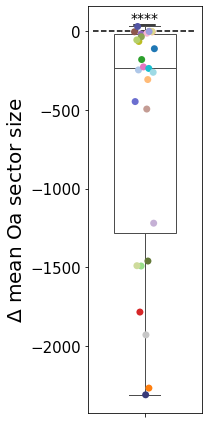

In [82]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_pivot.groupby("partner")["delta_sector_size_Oa"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_oa_ss, ax=ax, y="mean", hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_delta_oa_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r'$\Delta$ mean Oa sector size')
ax.legend([],[], frameon=False)
print(plt.gca().get_ylim())
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)

In [83]:
mean_delta_oa_ss[mean_delta_oa_ss["mean"] >0]

,partner,mean,std
1,AlFa,0.208439,0.444806
21,S1,31.228399,13.199890


Wilcoxon signed-ranktest: stat=317.0, p-value=0.004716595692289653


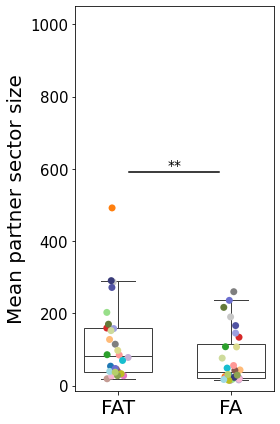

In [15]:
# Partner sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"], alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean partner sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
ax.set_xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 100, significance_stars(p_value), h = 0.0005)
ax.set_ylim(ax.get_ylim()[0], 1050)
plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_partner_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=89.0, p-value=0.009433191384579306


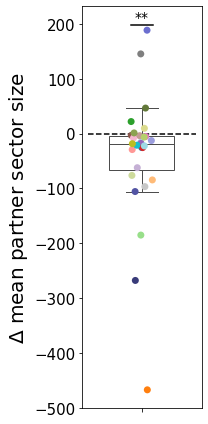

In [12]:
# Mean delta partner sector size
mean_delta_p_ss = data_pivot.groupby("partner")["delta_sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_p_ss["mean"] - 0)
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_p_ss, ax=ax, y="mean", hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_delta_p_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_p_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r'$\Delta$ mean partner sector size')
ax.legend([],[], frameon=False)
ax.set_xlabel("")
plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_delta_p_ss.pdf", dpi=600)

In [13]:
# Correlate partner sector size with effect of Oa on partners

for partner in all_partners_in_collection:
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_delta_p_ss.loc[mean_delta_p_ss["partner"] == partner, "oa_on_p"] = mean_oa_on_p_fa

mean_delta_p_ss.head()

,partner,mean,std,oa_on_p
0,AeCa,-16.028039,5.038290,-0.272455
1,AlFa,145.409201,68.609354,-0.075283
2,At,-25.331439,24.949691,-0.111893
3,BrVe,-467.210486,205.745357,2.235212
4,CiFr,-84.420384,95.257367,-0.226541


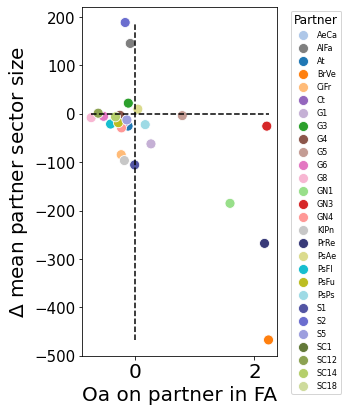

In [28]:
fig, ax = plt.subplots(figsize=(5,6))
sns.scatterplot(data=mean_delta_p_ss, ax=ax, x="oa_on_p", y="mean", hue="partner", palette=color_dict, s=100)
ax.hlines(y=0, xmin=mean_delta_p_ss["oa_on_p"].min(), xmax=mean_delta_p_ss["oa_on_p"].max(), color="black", linestyle="dashed")
ax.vlines(x=0, ymin=mean_delta_p_ss["mean"].min(), ymax=mean_delta_p_ss["mean"].max(), color="black", linestyle="dashed")
ax.set_ylabel(r'$\Delta$ mean partner sector size')
# legend outside
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Partner", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=12)
ax.set_xlabel("Oa on partner in FA")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_p_ss_vs_oa_on_p.pdf")
plt.show()

## Delta Oa sector size colored by delta Oa frequency

Wilcoxon signed-rank test: stat=9.0, p-value=4.988849443894224e-06
(-2428.532264955441, 148.35985870654736)


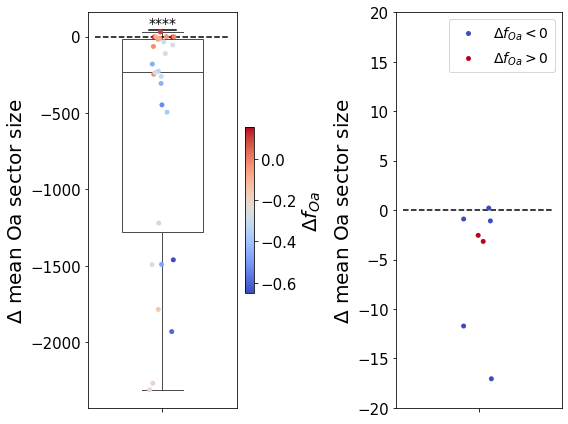

In [86]:
# Mean delta Oa sector size
data_plot = data_pivot.copy()
data_plot.columns = [
    "_".join([str(x) for x in col if x != ""]).strip("_")
    for col in data_plot.columns
]
mean_delta_oa_ss = (
    data_plot.groupby("partner")
    .agg(
        mean=("delta_sector_size_Oa", "mean"),
        sign_delta_oa_frequency=("sign_delta_oa_frequency", "first"),
        delta_oa_frequency=("delta_oa_frequency", "first")
    )
    .reset_index()
)
color_dict_delta = {1: "red", -1: "blue", 0: "gray"}
fig, ax = plt.subplots(figsize=(8,6),ncols=2)
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_oa_ss, ax=ax[0], y="mean", hue="delta_oa_frequency", palette="coolwarm", size=5)
sns.boxplot(data=mean_delta_oa_ss, ax=ax[0], y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax[0].hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
ax[0].set_ylabel(r'$\Delta$ mean Oa sector size')
ax[0].legend([],[], frameon=False)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=Normalize(vmin=mean_delta_oa_ss["delta_oa_frequency"].min(), vmax=mean_delta_oa_ss["delta_oa_frequency"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax[0], label=r'$\Delta f_{Oa}$', orientation='vertical', fraction=0.05, pad=0.05)
# Zoom in on the second subplot
sns.stripplot(data=mean_delta_oa_ss, ax=ax[1], y="mean", hue="sign_delta_oa_frequency", palette="coolwarm", size=5)
ax[1].hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax[0], -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax[1].set_ylabel(r'$\Delta$ mean Oa sector size')
# sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=Normalize(vmin=mean_delta_oa_ss["delta_oa_frequency"].min(), vmax=mean_delta_oa_ss["delta_oa_frequency"].max()))
# sm.set_array([])
# plt.colorbar(sm, ax=ax[1], label=r'$\Delta f_{Oa}$', orientation='vertical', fraction=0.05, pad=0.05)
handles, labels = ax[1].get_legend_handles_labels()
new_labels = [r'$\Delta f_{Oa} < 0$', r'$\Delta f_{Oa} > 0$', "Oa frequency unchanged"]
ax[1].legend(handles, new_labels, title="", loc="upper right", fontsize=14, title_fontsize=12, frameon=True)
print(plt.gca().get_ylim())
ax[0].set_xlabel("")
ax[1].set_xlabel("")
ax[1].set_ylim(-20, 20)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss_by_delta_freq.pdf", dpi=600)

## Sector sizes for patterns with no Oa dominance

Wilcoxon signed-ranktest: stat=181.0, p-value=6.29425048828125e-05
(-17.169826169847674, 588.3981186694446)


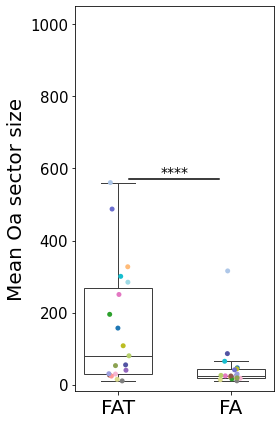

In [87]:
# Oa sector size distributions
mean_sector_size = data_no_dom.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"],alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=5)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean Oa sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
ax.set_xlabel("")
print(plt.gca().get_ylim())
ax.set_ylim(plt.gca().get_ylim()[0], 1050)
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 10, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_no_dom_oa_ss.pdf", dpi=600)
plt.show()

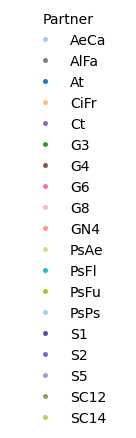

In [88]:
handles, labels = ax.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(2, 4))
ax_leg.axis("off")

ax_leg.legend(
    handles,
    labels,
    title="Partner",
    loc="center",
    fontsize=14,
    title_fontsize=14,
    frameon=False,
)

fig_leg.tight_layout()
fig_leg.savefig(plot_dir /"legend_no_dom.pdf", dpi=300, bbox_inches="tight")

Wilcoxon signed-rank test: stat=9.0, p-value=6.29425048828125e-05
(-470.82339708556697, 65.6118173794105)


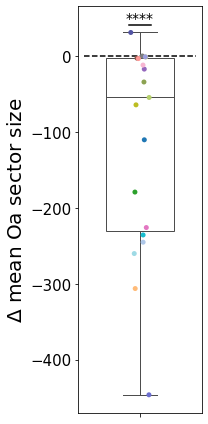

In [89]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_no_dom_pivot.groupby("partner")["delta_sector_size_Oa"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_oa_ss, ax=ax, y="mean", hue="partner", palette=color_dict, size=5)
sns.boxplot(data=mean_delta_oa_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r'$\Delta$ mean Oa sector size')
ax.legend([],[], frameon=False)
print(plt.gca().get_ylim())
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_no_dom_delta_oa_ss.pdf", dpi=600)

In [90]:
mean_delta_oa_ss[mean_delta_oa_ss["mean"] >0]

,partner,mean,std
1,AlFa,0.208439,0.444806
14,S1,31.228399,13.199890


## Sector sizes (of all patterns and of patterns where Oa does not dominate in FAT) normalized to abundances

In [91]:
# # Relative sector size distributions
# mean_sector_size = data.groupby(["partner", "media"])["norm_oa_ss"].agg(["mean", "std"]).reset_index()
# stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"])
# print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
# fig, ax = plt.subplots(figsize=(4,6))
# sns.stripplot(data=mean_sector_size, ax=ax,x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=5)
# sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
# ax.set_ylabel("Mean normalized Oa sector size")
# ax.set_xticks([0, 1])
# ax.set_xlabel("")
# ax.set_xticklabels(media_titles)
# ax.legend([],[], frameon=False)
# add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 0.01, significance_stars(p_value), h = 0.0005)
# plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_normalized_oa_ss.pdf", dpi=600)
# plt.show()

In [92]:
# # Relative sector size distributions
# mean_sector_size = data_no_dom.groupby(["partner", "media"])["norm_oa_ss"].agg(["mean", "std"]).reset_index()
# stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"])
# print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
# fig, ax = plt.subplots(figsize=(4,6))
# sns.stripplot(data=mean_sector_size, ax=ax,x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=5)
# sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
# ax.set_ylabel("Mean normalized Oa sector size")
# ax.set_xticks([0, 1])
# ax.set_xlabel("")
# ax.set_xticklabels(media_titles)
# ax.legend([],[], frameon=False)
# add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 0.01, significance_stars(p_value), h = 0.0005)
# plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_no_dom_normalized_oa_ss.pdf", dpi=600)
# plt.show()

In [93]:
# mean_sector_size = data.groupby(["partner", "media"])["norm_p_ss"].agg(["mean", "std"]).reset_index()
# stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == "FAT"]["mean"], mean_sector_size[mean_sector_size["media"] == "FA"]["mean"])
# print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
# fig, ax = plt.subplots(figsize=(4,6))
# sns.stripplot(data=mean_sector_size, x="media", y="mean", hue="partner", palette=color_dict, order=media_titles, size=5)
# sns.boxplot(data=mean_sector_size, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
# plt.ylabel("Mean normalized partner sector size")
# plt.xlabel("Media")
# plt.xticks([0, 1], media_titles)
# plt.legend([],[], frameon=False)
# add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 0.01, significance_stars(p_value), h = 0.0005)
# plt.xlabel("")
# plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_normalized_partner_ss.pdf", dpi=600)
# plt.show()

In [94]:
# # Mean delta Oa sector size
# mean_delta_oa_ss = data_pivot.groupby("partner")["delta_norm_oa_ss"].agg(["mean", "std"]).reset_index()
# stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
# print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
# plt.figure(figsize=(3,6))
# sns.stripplot(data=mean_delta_oa_ss, y="mean", hue="partner", palette=color_dict, size=5)
# sns.boxplot(data=mean_delta_oa_ss, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
# plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
# plt.ylabel("Mean delta normalized Oa sector size")
# plt.xlabel("Partner")
# plt.legend([],[], frameon=False)
# plt.xlabel("")
# add_sig_bar(plt.gca(), -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 0.01, significance_stars(p), h = 0.0005)
# plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_delta_norm_oa_ss.pdf", dpi=600)

In [95]:
# mean_delta_oa_ss[mean_delta_oa_ss["mean"] >0]

In [96]:
# # Mean delta partner sector size
# mean_delta_p_ss = data_pivot.groupby("partner")["delta_norm_p_ss"].agg(["mean", "std"]).reset_index()
# mean_delta_p_ss["partner"] = mean_delta_p_ss["partner"].astype(str)
# plt.figure(figsize=(3,6))
# sns.stripplot(data=mean_delta_p_ss, y="mean", hue="partner", palette=color_dict,size=5)
# sns.boxplot(data=mean_delta_p_ss, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
# plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
# plt.ylabel("Mean delta normalized partner sector size")
# plt.xlabel("Partner")
# plt.legend([],[], frameon=False)
# plt.xlabel("")
# plt.tight_layout()
# plt.savefig(plot_dir / f"{plots_prefix}_delta_norm_p_ss.pdf", dpi=600)
# plt.show()

## Repeat the analysis with the partner subset

In [131]:
data_subset = data[data["partner"].isin(partner_subset)]
data_pivot_subset = data_pivot[data_pivot["partner"].isin(partner_subset)]

In [132]:
mean_intermixing_subset = data_subset.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
print(f"Median mixing in {media[0]}: {mean_intermixing_subset[mean_intermixing_subset['media'] == media[0]]['mean'].median()}")
print(f"Median mixing in {media[1]}: {mean_intermixing_subset[mean_intermixing_subset['media'] == media[1]]['mean'].median()}")
mean_oa_sector_size_subset = data_subset.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
print(f"Median Oa sector size in {media[0]}: {mean_oa_sector_size_subset[mean_oa_sector_size_subset['media'] == media[0]]['mean'].median()}")
print(f"Median Oa sector size in {media[1]}: {mean_oa_sector_size_subset[mean_oa_sector_size_subset['media'] == media[1]]['mean'].median()}")
mean_partner_sector_size_subset = data_subset.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
# mean_rel_sector_size_subset = data_subset.groupby(["partner", "media"])["rel_oa_ss"].agg(["mean", "std"]).reset_index()

stat_mix, p_value_mix = wilcoxon(mean_intermixing_subset[mean_intermixing_subset["media"] == "FAT"]["mean"], mean_intermixing_subset[mean_intermixing_subset["media"] == "FA"]["mean"],alternative="less")
print(f"Mixing in FA is greater than in FAT: stat={stat_mix}, p-value={p_value_mix}")
stat_oa_ss, p_value_oa_ss = wilcoxon(mean_oa_sector_size_subset[mean_oa_sector_size_subset["media"] == "FAT"]["mean"], mean_oa_sector_size_subset[mean_oa_sector_size_subset["media"] == "FA"]["mean"],alternative="greater")
print(f"Oa sector size in FAT is less than in FA: stat={stat_oa_ss}, p-value={p_value_oa_ss}")
stat_partner_ss, p_value_partner_ss = wilcoxon(mean_partner_sector_size_subset[mean_partner_sector_size_subset["media"] == "FAT"]["mean"], mean_partner_sector_size_subset[mean_partner_sector_size_subset["media"] == "FA"]["mean"],alternative="two-sided")
print(f"Partner sector size in FAT is less than in FA: stat={stat_partner_ss}, p-value={p_value_partner_ss}")
# stat_rel_ss, p_value_rel_ss = wilcoxon(mean_rel_sector_size_subset[mean_rel_sector_size_subset["media"] == "FAT"]["mean"], mean_rel_sector_size_subset[mean_rel_sector_size_subset["media"] == "FA"]["mean"],alternative="greater")
# print(f"Relative Oa sector size in FAT is less than in FA: stat={stat_rel_ss}, p-value={p_value_rel_ss}")

Median mixing in FAT: 0.02175342611182207
Median mixing in FA: 0.03838764751177373
Median Oa sector size in FAT: 33.22017270968437
Median Oa sector size in FA: 21.69746037421681
Mixing in FA is greater than in FAT: stat=4.0, p-value=0.02734375
Oa sector size in FAT is less than in FA: stat=29.0, p-value=0.07421875
Partner sector size in FAT is less than in FA: stat=15.0, p-value=0.7421875


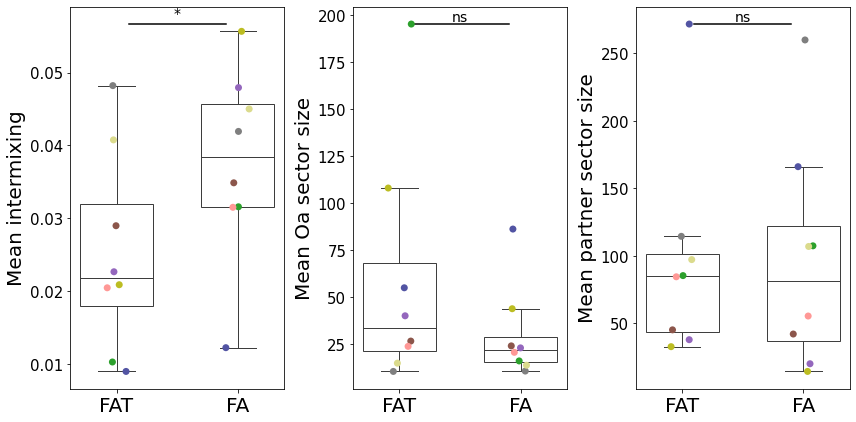

In [99]:
# Absolute values of mixing and sector sizes
fig, ax = plt.subplots(ncols=3,nrows=1,figsize=(12,6))
# Mixing
sns.stripplot(data=mean_intermixing_subset, ax=ax[0], x="media", y="mean", hue="partner", order=media_titles, palette=color_dict, size=7)
sns.boxplot(data=mean_intermixing_subset, ax=ax[0], x="media", y="mean", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax[0].set_ylabel("Mean intermixing")
add_sig_bar(ax[0], 0.1, 0.9, mean_intermixing_subset["mean"].max() + 0.001, significance_stars(p_value_mix), h = 0.0005)
# Oa sector size
sns.stripplot(data=mean_oa_sector_size_subset, ax=ax[1], x="media", y="mean", hue="partner", order=media_titles, palette=color_dict, size=7)
sns.boxplot(data=mean_oa_sector_size_subset, ax=ax[1], x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax[1].set_ylabel("Mean Oa sector size")
add_sig_bar(ax[1], 0.1, 0.9, mean_oa_sector_size_subset["mean"].max() + 0.001, significance_stars(p_value_oa_ss), h = 0.0005)
# Partner sector size
sns.stripplot(data=mean_partner_sector_size_subset, ax=ax[2], x="media", y="mean", hue="partner", order=media_titles, palette=color_dict, size=7)
sns.boxplot(data=mean_partner_sector_size_subset, ax=ax[2], x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax[2].set_ylabel("Mean partner sector size")
add_sig_bar(ax[2], 0.1, 0.9, mean_partner_sector_size_subset["mean"].max() + 0.001, significance_stars(p_value_partner_ss), h = 0.0005)
# Relative Oa sector size
for i in range(3):
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(media_titles)
    ax[i].legend([],[], frameon=False)
    ax[i].set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_subset_absolute_values.pdf", dpi=600)
plt.show()

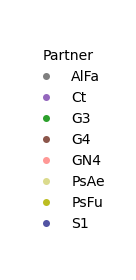

In [100]:
handles, labels = ax[0].get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(2, 4))
ax_leg.axis("off")

ax_leg.legend(
    handles,
    labels,
    title="Partner",
    loc="center",
    fontsize=14,
    title_fontsize=14,
    frameon=False,
)

fig_leg.tight_layout()
fig_leg.savefig(plot_dir /"legend_subset.pdf", dpi=300, bbox_inches="tight")

Mean delta intermixing: stat=32.0, p-value=0.02734375
Mean delta Oa sector size: stat=7.0, p-value=0.07421875
Mean delta partner sector size: stat=15.0, p-value=0.37109375


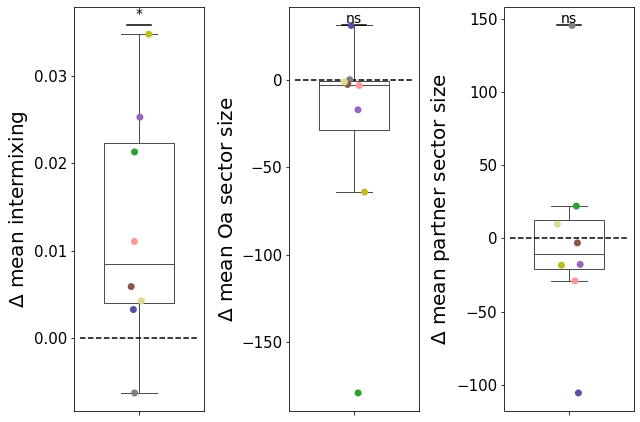

In [101]:
# Slopes
mean_delta_intermixing_subset = data_pivot_subset.groupby("partner")["delta_mean_intermixing"].agg(["mean", "std"]).reset_index()
mean_delta_oa_ss_subset = data_pivot_subset.groupby("partner")["delta_sector_size_Oa"].agg(["mean", "std"]).reset_index()
mean_delta_p_ss_subset = data_pivot_subset.groupby("partner")["delta_sector_size_partner"].agg(["mean", "std"]).reset_index()
# p-values
stat_delta_mix, p_delta_mix = wilcoxon(mean_delta_intermixing_subset["mean"] - 0, alternative="greater")
print(f"Mean delta intermixing: stat={stat_delta_mix}, p-value={p_delta_mix}")
stat_delta_oa_ss, p_delta_oa_ss = wilcoxon(mean_delta_oa_ss_subset["mean"] - 0, alternative="less")
print(f"Mean delta Oa sector size: stat={stat_delta_oa_ss}, p-value={p_delta_oa_ss}")
stat_delta_p_ss, p_delta_p_ss = wilcoxon(mean_delta_p_ss_subset["mean"] - 0, alternative="less")
print(f"Mean delta partner sector size: stat={stat_delta_p_ss}, p-value={p_delta_p_ss}")

fig, ax = plt.subplots(figsize=(9,6),nrows=1,ncols=3)
# Mixing
sns.stripplot(data=mean_delta_intermixing_subset, ax=ax[0], y="mean", hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_delta_intermixing_subset, ax=ax[0], y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
add_sig_bar(ax[0], -0.1, 0.1, mean_delta_intermixing_subset["mean"].max() + 0.001, significance_stars(p_delta_mix), h = 0.0005)
ax[0].set_ylabel(r'$\Delta$ mean intermixing')
# Oa sector size
sns.stripplot(data=mean_delta_oa_ss_subset, ax=ax[1], y="mean", hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_delta_oa_ss_subset, ax=ax[1], y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
add_sig_bar(ax[1], -0.1, 0.1, mean_delta_oa_ss_subset["mean"].max() + 0.001, significance_stars(p_delta_oa_ss), h = 0.0005)
ax[1].set_ylabel(r'$\Delta$ mean Oa sector size')
# Partner sector size
sns.stripplot(data=mean_delta_p_ss_subset, ax=ax[2], y="mean", hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_delta_p_ss_subset, ax=ax[2], y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
add_sig_bar(ax[2], -0.1, 0.1, mean_delta_p_ss_subset["mean"].max() + 0.001, significance_stars(p_delta_p_ss), h = 0.0005)
ax[2].set_ylabel(r'$\Delta$ mean partner sector size')
# Relative Oa sector size
for i in range(3):
    ax[i].legend([],[], frameon=False)
    ax[i].set_xlabel("")
    ax[i].hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_subset_slopes.pdf", dpi=600)
plt.show()

## Does Oa in FA have the smallest sectors

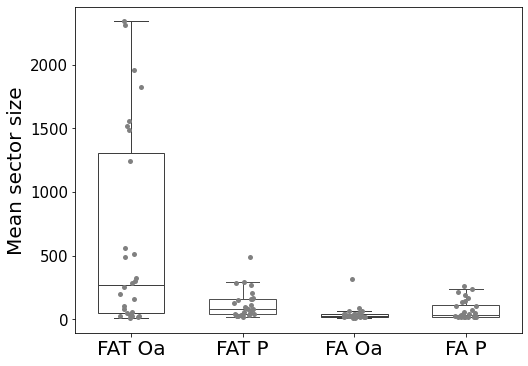

In [102]:
# All sector sizes in a single plot
mean_sector_size_oa = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
mean_sector_size_p = data.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(8,6))
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]=="FAT"], ax=ax, x=1, y="mean", size=5,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]=="FAT"], ax=ax, x=1, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]=="FAT"], ax=ax, x=2, y="mean", size=5,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]=="FAT"], ax=ax, x=2, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]=="FA"], ax=ax, x=3, y="mean", size=5,color="gray")
sns.boxplot(data=mean_sector_size_oa[mean_sector_size_oa["media"]=="FA"], ax=ax, x=3, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
sns.stripplot(data=mean_sector_size_p[mean_sector_size_p["media"]=="FA"], ax=ax, x=4, y="mean", size=5,color="gray")
sns.boxplot(data=mean_sector_size_p[mean_sector_size_p["media"]=="FA"], ax=ax, x=4, y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_xticks([0,1, 2, 3])
ax.set_xticklabels(["FAT Oa", "FAT P", "FA Oa", "FA P"])
ax.set_ylabel("Mean sector size")
plt.savefig(plot_dir / f"{plots_prefix}_all_sector_sizes.pdf", dpi=600)
plt.show()


In [103]:
# Oa sector size is smaller in FA than FAT
oa_fa = mean_sector_size_oa[mean_sector_size_oa["media"]=="FA"]["mean"]
oa_fat = mean_sector_size_oa[mean_sector_size_oa["media"]=="FAT"]["mean"]
partner_fa = mean_sector_size_p[mean_sector_size_p["media"]=="FA"]["mean"]
partner_fat = mean_sector_size_p[mean_sector_size_p["media"]=="FAT"]["mean"]
res1 = wilcoxon(
    oa_fa,
    oa_fat,
    alternative="less"
)

# Oa sector size is smaller than partner sector size in FA
res2 = wilcoxon(
    oa_fa,
    partner_fa,
    alternative="less"
)

# Oa sector size in FA is smaller than partner sector size in FAT
res3 = wilcoxon(
    oa_fa,
    partner_fat,
    alternative="less"
)

In [104]:
def holm_correction(p_values, alpha=0.05):
    """
    Holm–Bonferroni correction.

    Parameters
    ----------
    p_values : array-like
        Raw p-values.
    alpha : float
        Family-wise significance level.

    Returns
    -------
    adjusted_p_values : np.ndarray
        Holm-adjusted p-values, returned in the original order.
    reject : np.ndarray of bool
        Whether each null hypothesis is rejected.
    """
    p_values = np.asarray(p_values, dtype=float)

    if np.any((p_values < 0) | (p_values > 1)):
        raise ValueError("All p-values must be between 0 and 1.")

    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]

    # Initial Holm adjustment
    adjusted_sorted = (m - np.arange(m)) * sorted_p

    # Enforce monotonicity
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)

    # P-values cannot exceed 1
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)

    # Restore original order
    adjusted_p_values = np.empty(m)
    adjusted_p_values[order] = adjusted_sorted

    reject = adjusted_p_values <= alpha

    return adjusted_p_values, reject

In [105]:
p_adjusted, reject = holm_correction([res1.pvalue, res2.pvalue, res3.pvalue])

for name, raw, adjusted, significant in zip(
    [
        "Oa-FA vs Oa-FAT",
        "Oa-FA vs Partner-FA",
        "Oa-FA vs Partner-FAT"
    ],
    [res1.pvalue, res2.pvalue, res3.pvalue],
    p_adjusted,
    reject
):
    print(
        f"{name}: raw p = {raw:.4g}, "
        f"Holm-adjusted p = {adjusted:.4g}, "
        f"significant = {significant}"
    )

Oa-FA vs Oa-FAT: raw p = 4.989e-06, Holm-adjusted p = 1.497e-05, significant = True
Oa-FA vs Partner-FA: raw p = 0.03601, Holm-adjusted p = 0.03601, significant = True
Oa-FA vs Partner-FAT: raw p = 7.153e-05, Holm-adjusted p = 0.0001431, significant = True


## Effect of partners: mixed model fitting

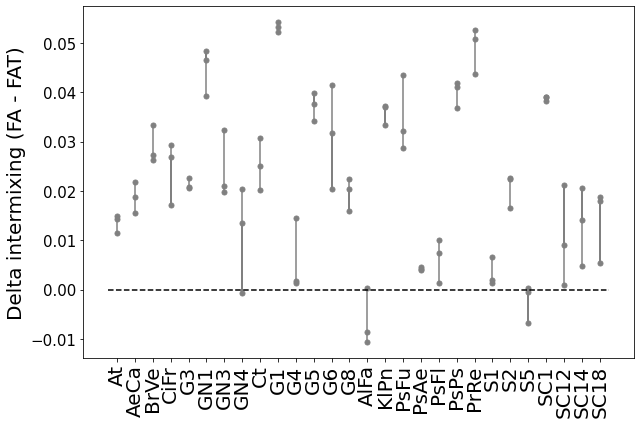

In [106]:
# Delta mixing across partners
fig, ax = plt.subplots(figsize=(9,6))
for i, partner in enumerate(all_partners_in_collection):

    # Delta mixing
    delta_mixing = data_pivot[data_pivot["partner"] == partner]["delta_mean_intermixing"].values
    # Plots
    ax.plot([i,i,i], delta_mixing, marker="o", markersize=5, color="gray")
plt.hlines(0, -0.5, len(all_partners_in_collection)-0.5, color="black", linestyle="dashed")
plt.xticks(range(len(all_partners_in_collection)), all_partners_in_collection, rotation=90)
ax.set_ylabel("Delta intermixing (FA - FAT)")
plt.tight_layout()
plt.show()

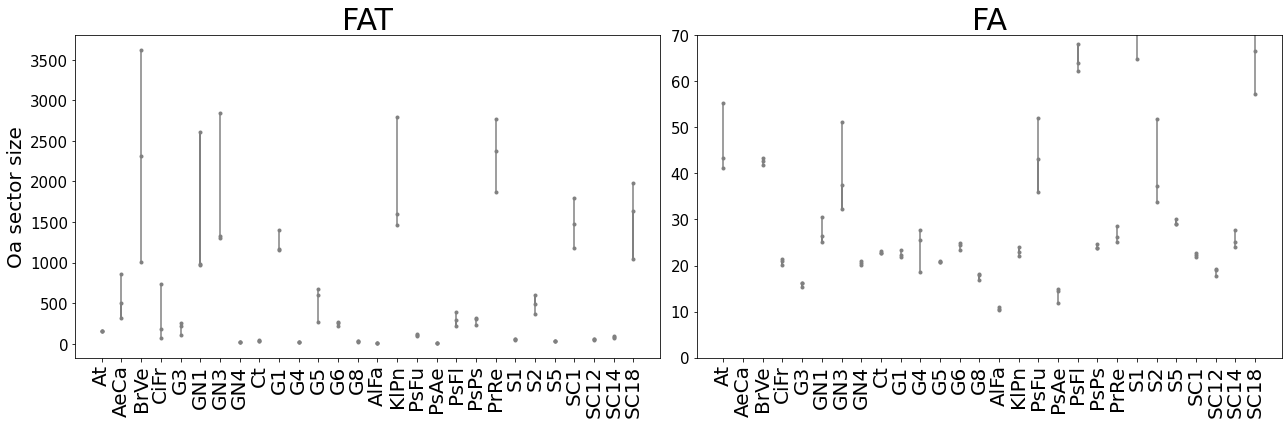

In [107]:
# Oa sector size in FAT and in FA across partners
fig, ax = plt.subplots(figsize=(18,6),ncols=2,nrows=1)
for i, partner in enumerate(all_partners_in_collection):

    # Oa sector size
    oa_ss_fat = data[(data["partner"] == partner)&(data["media"] == "FAT")]["sector_size_Oa"].values
    oa_ss_fa = data[(data["partner"] == partner)&(data["media"] == "FA")]["sector_size_Oa"].values
    # Plots
    ax[0].plot([i,i,i], oa_ss_fat, marker="o", markersize=3, color="gray")
    ax[1].plot([i,i,i], oa_ss_fa, marker="o", markersize=3, color="gray")
for i in range(2):
    ax[i].set_xticks(range(len(all_partners_in_collection)))
    ax[i].set_xticklabels(all_partners_in_collection, rotation=90)
ax[0].set_ylabel("Oa sector size")
ax[0].set_title("FAT")
ax[1].set_title("FA")
ax[1].set_ylim(0,70)
plt.tight_layout()
plt.show()

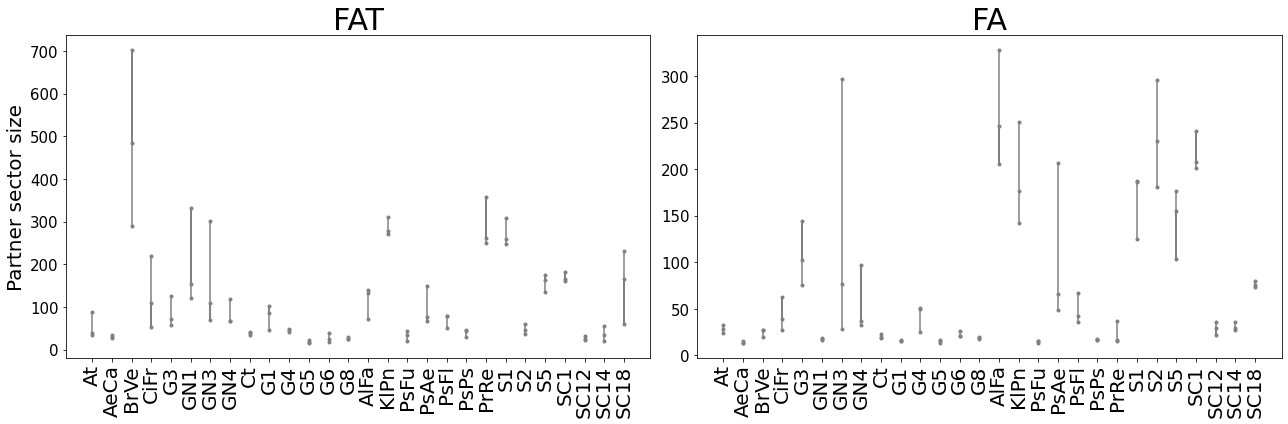

In [108]:
# Partner sector size in FAT and in FA 
fig, ax = plt.subplots(figsize=(18,6),ncols=2,nrows=1)
for i, partner in enumerate(all_partners_in_collection):

    # Oa sector size
    p_ss_fat = data[(data["partner"] == partner)&(data["media"] == "FAT")]["sector_size_partner"].values
    p_ss_fa = data[(data["partner"] == partner)&(data["media"] == "FA")]["sector_size_partner"].values
    # Plots
    ax[0].plot([i,i,i], p_ss_fat, marker="o", markersize=3, color="gray")
    ax[1].plot([i,i,i], p_ss_fa, marker="o", markersize=3, color="gray")
for i in range(2):
    ax[i].set_xticks(range(len(all_partners_in_collection)))
    ax[i].set_xticklabels(all_partners_in_collection, rotation=90)
ax[0].set_ylabel("Partner sector size")
ax[0].set_title("FAT")
ax[1].set_title("FA")
plt.tight_layout()
plt.show()

In [109]:
# Fit a mixed linear model to test if the effect of partner on delta intermixing is significant
statsmodels_installed = False
if statsmodels_installed:
    model = mixedlm(
        "delta_mean_intermixing ~ 1",  # fixed effect of media
        data=data_pivot,
        groups=data_pivot["partner"] # random effect of partner
    )

    result = model.fit()
    print(result.summary())

    # Between-group variance
    sigma_alpha2 = result.cov_re.iloc[0, 0]
    # Residual variance
    sigma_eps2 = result.scale
    # Interclass correlation coefficient (ICC)
    icc = sigma_alpha2 / (sigma_alpha2 + sigma_eps2)
    print(icc)

In [110]:
# Fit a mixed linear model to test if the effect of partner on delta intermixing is significant
if not statsmodels_installed:
    grand_mean = data_pivot["delta_mean_intermixing"].mean()

    group_stats = data_pivot.groupby("partner")["delta_mean_intermixing"].agg(["mean", "count"])

    # Between
    SSB = np.sum(group_stats["count"] *
                (group_stats["mean"] - grand_mean)**2)

    # Within
    SSW = (
    data_pivot.groupby("partner")["delta_mean_intermixing"]
      .apply(lambda x: np.sum((x - x.mean())**2))
      .sum()
)

    k = len(group_stats)
    N = len(data_pivot)

    MSB = SSB / (k - 1)
    MSW = SSW / (N - k)

    n0 = (N - np.sum(group_stats["count"]**2)/N)/(k-1)

    sigma_eps2 = MSW
    sigma_alpha2 = max(0, (MSB - MSW)/n0)
    icc = sigma_alpha2 / (sigma_alpha2 + sigma_eps2)
    print(icc)

0.8820670608154481


In [111]:
def get_interclass_correlation_coefficient(data, group_col, value_col):
    grand_mean = data[value_col].mean()
    group_stats = data.groupby(group_col)[value_col].agg(["mean", "count"])

    # Between-group sum of squares
    SSB = np.sum(group_stats["count"] * (group_stats["mean"] - grand_mean)**2)

    # Within-group sum of squares
    SSW = (
        data.groupby(group_col)[value_col]
        .apply(lambda x: np.sum((x - x.mean())**2))
        .sum()
    )

    k = len(group_stats)
    N = len(data)

    MSB = SSB / (k - 1)
    MSW = SSW / (N - k)

    n0 = (N - np.sum(group_stats["count"]**2) / N) / (k - 1)

    sigma_eps2 = MSW
    sigma_alpha2 = max(0, (MSB - MSW) / n0)
    icc = sigma_alpha2 / (sigma_alpha2 + sigma_eps2)
    
    return icc

In [112]:
print(f'Variance of delta intermixing explained by partner:{get_interclass_correlation_coefficient(data_pivot, "partner", "delta_mean_intermixing")}')
print(f'Variance of Oa sector size in FA explained by partner:{get_interclass_correlation_coefficient(data[data["media"] == "FA"], "partner", "sector_size_Oa")}')
print(f'Variance of partner sector in FA size explained by partner:{get_interclass_correlation_coefficient(data[data["media"] == "FA"], "partner", "sector_size_partner")}')
print(f'Variance of Oa sector size in FAT explained by partner:{get_interclass_correlation_coefficient(data[data["media"] == "FAT"], "partner", "sector_size_Oa")}')
print(f'Variance of partner sector in FAT size explained by partner:{get_interclass_correlation_coefficient(data[data["media"] == "FAT"], "partner", "sector_size_partner")}')

Variance of delta intermixing explained by partner:0.8820670608154481
Variance of Oa sector size in FA explained by partner:0.7671302616947888
Variance of partner sector in FA size explained by partner:0.7672716554332265
Variance of Oa sector size in FAT explained by partner:0.7657872372014607
Variance of partner sector in FAT size explained by partner:0.7544378254061811
